<a href="https://colab.research.google.com/github/bollasaikrishnareddy23/ai_support_disk/blob/main/Copy_of_Multi_Agent_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Upload the Project ZIP File

This cell opens a file upload window in Google Colab.  
Upload the `icu_deterioration_3_agents_starter.zip` file here so it can be extracted and used in the next step.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving icu_deterioration_3_agents_starter.zip to icu_deterioration_3_agents_starter.zip


In [2]:
!unzip icu_deterioration_3_agents_starter.zip

Archive:  icu_deterioration_3_agents_starter.zip
  inflating: icu_deterioration_3_agents_starter/README.md  
  inflating: icu_deterioration_3_agents_starter/requirements.txt  
  inflating: icu_deterioration_3_agents_starter/PROJECT_STEPS.md  
  inflating: icu_deterioration_3_agents_starter/sql/01_create_cohort_bigquery.sql  
  inflating: icu_deterioration_3_agents_starter/sql/02_create_features_bigquery.sql  
  inflating: icu_deterioration_3_agents_starter/src/create_sample_data.py  
  inflating: icu_deterioration_3_agents_starter/src/run_rule_based_agents.py  
  inflating: icu_deterioration_3_agents_starter/src/train_ml_baseline.py  
  inflating: icu_deterioration_3_agents_starter/src/train_3_ml_agents.py  
  inflating: icu_deterioration_3_agents_starter/src/__init__.py  
  inflating: icu_deterioration_3_agents_starter/src/agents/kidney_failure_agent.py  
  inflating: icu_deterioration_3_agents_starter/src/agents/vital_signs_agent.py  
  inflating: icu_deterioration_3_agents_starter/s

In [3]:
%cd icu_deterioration_3_agents_starter

/content/icu_deterioration_3_agents_starter


In [4]:
!pip install -r requirements.txt


### Generate Data and Run Prediction Agents

This cell runs the main project pipeline.  
First, it creates sample ICU patient data. Then it runs rule-based agents that use predefined clinical logic to make predictions. After that, it trains a baseline machine learning model and finally trains three separate ML agents for comparison.

The outputs from these scripts are saved in the `results/` folder and are used in the following cells for evaluation and analysis.

In [5]:
# Generate a sample ICU patient dataset for testing the project pipeline
!python src/create_sample_data.py
# Run the rule-based agents to make predictions using predefined medical rules
!python src/run_rule_based_agents.py
# Train a single machine learning baseline model for ICU deterioration prediction
!python src/train_ml_baseline.py
# Train three separate machine learning agents and compare their performance
!python src/train_3_ml_agents.py

Created data/sample_features.csv
   subject_id  hadm_id  ...  creatinine_trend_24h  hospital_expire_flag
0      100000   200000  ...             -0.508383                     0
1      100001   200001  ...             -2.336393                     0
2      100002   200002  ...              2.115978                     1
3      100003   200003  ...              1.635976                     1
4      100004   200004  ...              1.426058                     0

[5 rows x 24 columns]
Saved results/rule_based_predictions.csv
   subject_id  ...                                  final_explanation
0      100000  ...  Mechanical Ventilation Agent indicates medium ...
1      100001  ...  No major kidney, vital sign, or ventilation ri...
2      100002  ...  Vital Signs Agent indicates medium risk becaus...
3      100003  ...  Kidney Failure Agent indicates medium risk bec...
4      100004  ...  Kidney Failure Agent indicates medium risk bec...
5      100005  ...  Kidney Failure Agent indicates 

### Preview Rule-Based Agent Predictions

This cell reads the `rule_based_predictions.csv` file created by the rule-based agents.  
It displays the first five rows of the prediction table so we can quickly check whether the agents produced results correctly.

The table should include patient IDs, true labels, individual agent risk scores, overall risk level, and explanation text.

In [6]:
import pandas as pd
# Load the rule-based agent prediction results from the results folder
# The .head() function displays the first 5 rows so we can quickly preview the output
pd.read_csv("results/rule_based_predictions.csv").head()

,subject_id,hadm_id,stay_id,true_label,kidney_risk,kidney_score,kidney_reasons,vital_risk,vital_score,vital_reasons,ventilation_risk,ventilation_score,ventilation_reasons,overall_risk,total_score,final_explanation
0,100000,200000,300000,0,low,0,NaN,low,1,abnormal temperature,medium,2,high PEEP; oxygen or respiratory support required,low,3,Mechanical Ventilation Agent indicates medium ...
1,100001,200001,300001,0,low,0,NaN,low,1,low systolic blood pressure,low,1,high PEEP,low,2,"No major kidney, vital sign, or ventilation ri..."
2,100002,200002,300002,1,low,1,creatinine is increasing,medium,3,very high heart rate; low systolic blood press...,medium,3,patient is mechanically ventilated,medium,7,Vital Signs Agent indicates medium risk becaus...
3,100003,200003,300003,1,medium,3,high creatinine; creatinine is increasing,high,4,low mean arterial pressure; low oxygen saturation,medium,3,high oxygen requirement; oxygen or respiratory...,high,10,Kidney Failure Agent indicates medium risk bec...
4,100004,200004,300004,0,medium,2,creatinine is increasing; high BUN,high,5,low mean arterial pressure; low systolic blood...,medium,2,high oxygen requirement,high,9,Kidney Failure Agent indicates medium risk bec...


In [7]:
# Import the json library so we can read data stored in JSON format
import json
# Open the metrics file created by the three machine learning agents
with open("results/three_ml_agent_metrics.json") as f:
    metrics = json.load(f)
# Display the loaded metrics so we can review model performance
metrics

{'kidney_auroc': 0.6041666666666666,
 'kidney_auprc': 0.5302349191622026,
 'vital_auroc': 0.7349537037037037,
 'vital_auprc': 0.6750697320809476,
 'ventilation_auroc': 0.6458333333333334,
 'ventilation_auprc': 0.5643230565083509,
 'supervisor_auroc': 0.7430555555555556,
 'supervisor_auprc': 0.7692426526711866}

In [8]:
# Install the required Google BigQuery libraries in the Colab environment
# google-cloud-bigquery allows Python to connect to and query BigQuery datasets
# db-dtypes helps pandas correctly handle BigQuery-specific data types
!pip install google-cloud-bigquery db-dtypes -q

In [9]:
# Import the authentication module from Google Colab
from google.colab import auth
# Authenticate the current Google account so Colab can access Google Cloud services
auth.authenticate_user()
# Print a confirmation message after successful authentication
print("Authenticated")

Authenticated


In [10]:
# Import the BigQuery library so we can connect to Google BigQuery from Python
from google.cloud import bigquery
# Import the BigQuery library so we can connect to Google BigQuery from Python
project_id = "mimic-icu-project-496307"
# Create a BigQuery client using the selected Google Cloud project
# This client will be used to run SQL queries in later cells
client = bigquery.Client(project=project_id)
# Print a confirmation message when the BigQuery client is successfully created
print("BigQuery client created")

BigQuery client created


In [11]:
# Import the Google Drive module from Google Colab
from google.colab import drive
# Mount Google Drive so this notebook can access files stored in MyDrive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Search inside Google Drive for a folder named "icu_3_agent_project"
# This helps confirm the exact location of the project folder before changing directories

!find "/content/drive/MyDrive" -type d -name "icu_3_agent_project"

/content/drive/MyDrive/icu_3_agent_project


In [13]:
# Change the current working directory to the ICU 3-agent project folder in Google Drive
%cd /content/drive/MyDrive/icu_3_agent_project

/content/drive/MyDrive/icu_3_agent_project


In [14]:
import os
import glob

# Define the main project directory in Google Drive
project_dir = "/content/drive/MyDrive/icu_3_agent_project"

# Define the expected location of the raw PhysioNet 2012 ICU dataset
raw_dir = f"{project_dir}/raw_data/physionet2012"
set_a_dir = f"{raw_dir}/set-a"
outcomes_path = f"{raw_dir}/Outcomes-a.txt"

# Check whether the main project folder exists
print("Project exists:", os.path.exists(project_dir))
# Check whether the raw data folder exists
print("Raw data exists:", os.path.exists(raw_dir))
# Check whether the Set A patient files folder exists
print("Set A exists:", os.path.exists(set_a_dir))
# Check whether the outcomes file exists
print("Outcomes exists:", os.path.exists(outcomes_path))
# Count how many patient text files are available in the Set A folder
print("Number of patient files:", len(glob.glob(set_a_dir + "/*.txt")))

Project exists: True
Raw data exists: True
Set A exists: True
Outcomes exists: True
Number of patient files: 4000


In [15]:
# Define the main project directory path inside Google Drive
# This path will be reused later to locate raw data, processed data, and results
project_dir = "/content/drive/MyDrive/icu_3_agent_project"

In [16]:
# Import libraries for checking folders and searching files
import os
import glob
# Define the main project directory in Google Drive
project_dir = "/content/drive/MyDrive/icu_3_agent_project"
# Define paths for the raw PhysioNet 2012 ICU dataset
raw_dir = f"{project_dir}/raw_data/physionet2012"
set_a_dir = f"{raw_dir}/set-a"
outcomes_path = f"{raw_dir}/Outcomes-a.txt"
# Check whether the main project folder exists
print("Project exists:", os.path.exists(project_dir))
# Check whether the raw dataset folder exists
print("Raw data exists:", os.path.exists(raw_dir))
# Check whether the Set A patient records folder exists
print("Set A exists:", os.path.exists(set_a_dir))
# Check whether the outcomes file exists
print("Outcomes exists:", os.path.exists(outcomes_path))
# Count how many patient text files are inside the Set A folder
print("Number of patient files:", len(glob.glob(set_a_dir + "/*.txt")))

Project exists: True
Raw data exists: True
Set A exists: True
Outcomes exists: True
Number of patient files: 4000


In [17]:
# List the files and folders inside the raw PhysioNet 2012 dataset directory
# This helps confirm that the dataset folder contains the expected files, such as set-a and Outcomes-a.txt
!ls -la "/content/drive/MyDrive/icu_3_agent_project/raw_data/physionet2012"

total 82
-rw------- 1 root root 79219 May 14 07:26 Outcomes-a.txt
drwx------ 2 root root  4096 May 14 09:02 set-a


In [18]:
# Import libraries for data handling, numerical operations, and file path management
import pandas as pd
import numpy as np
import os
import glob
# Load the patient outcomes file into a pandas DataFrame
outcomes = pd.read_csv(outcomes_path)
# Print the number of rows and columns in the outcomes dataset
print(outcomes.shape)
# Display the first five rows to preview the outcomes data
outcomes.head()

(4000, 6)


,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0


In [19]:
# Get a sorted list of all patient record files inside the Set A folder
patient_files = sorted(glob.glob(set_a_dir + "/*.txt"))
# Print the total number of patient files found
print("Number of patient files:", len(patient_files))
# Print the path of the first patient file so we can confirm the file location
print("First patient file:", patient_files[0])
# Load the first patient file into a pandas DataFrame as a sample
sample_patient = pd.read_csv(patient_files[0])
# Display the first 20 rows of the sample patient record
sample_patient.head(20)

Number of patient files: 4000
First patient file: /content/drive/MyDrive/icu_3_agent_project/raw_data/physionet2012/set-a/132539.txt


,Time,Parameter,Value
0,00:00,RecordID,132539.00
1,00:00,Age,54.00
2,00:00,Gender,0.00
3,00:00,Height,-1.00
4,00:00,ICUType,4.00
5,00:00,Weight,-1.00
6,00:07,GCS,15.00
7,00:07,HR,73.00
8,00:07,NIDiasABP,65.00
9,00:07,NIMAP,92.33


In [20]:
# Create a folder to store processed intermediate data files
os.makedirs(f"{project_dir}/data/processed", exist_ok=True)
# Create a folder to store the final cleaned dataset used for modeling
os.makedirs(f"{project_dir}/data/final", exist_ok=True)
# Create a folder to store model outputs, metrics, predictions, and result files
os.makedirs(f"{project_dir}/results", exist_ok=True)
# Print a confirmation message after the folders are created
print("Output folders created")

Output folders created


### Extract Features from Patient Time-Series Data

This cell converts the raw ICU patient records into a structured feature table that can be used for machine learning.

Each patient file contains time-series clinical measurements. The code keeps only measurements from the first 24 hours, extracts static patient information such as age, gender, height, and weight, and calculates summary statistics for important clinical variables.

For each selected variable, the cell calculates the minimum, maximum, mean, first value, last value, and trend over the first 24 hours. These features are grouped around the three agent areas: kidney function, vital signs, and ventilation.

Finally, the extracted features from all patient files are combined into a single DataFrame called `features_df`, which will be used for model training and prediction.

In [21]:
def time_to_hours(t):
    try:
        h, m = str(t).split(":")
        return int(h) + int(m) / 60
    except:
        return np.nan


def get_static_value(df, parameter):
    values = df.loc[df["Parameter"] == parameter, "Value"]
    if len(values) == 0:
        return np.nan
    return pd.to_numeric(values.iloc[0], errors="coerce")


def summarize_variable(df, parameter, prefix):
    sub = df[df["Parameter"] == parameter].copy()
    values = pd.to_numeric(sub["Value"], errors="coerce").dropna()

    result = {}

    if len(values) == 0:
        result[f"{prefix}_min_24h"] = np.nan
        result[f"{prefix}_max_24h"] = np.nan
        result[f"{prefix}_mean_24h"] = np.nan
        result[f"{prefix}_first_24h"] = np.nan
        result[f"{prefix}_last_24h"] = np.nan
        result[f"{prefix}_trend_24h"] = np.nan
    else:
        result[f"{prefix}_min_24h"] = values.min()
        result[f"{prefix}_max_24h"] = values.max()
        result[f"{prefix}_mean_24h"] = values.mean()
        result[f"{prefix}_first_24h"] = values.iloc[0]
        result[f"{prefix}_last_24h"] = values.iloc[-1]
        result[f"{prefix}_trend_24h"] = values.iloc[-1] - values.iloc[0]

    return result


def extract_features_from_file(file_path):
    df = pd.read_csv(file_path)

    df.columns = [c.strip() for c in df.columns]
    df["Parameter"] = df["Parameter"].astype(str).str.strip()

    df["hours"] = df["Time"].apply(time_to_hours)

    # Use first 24 hours only
    df = df[df["hours"] <= 24].copy()

    record_id = int(os.path.basename(file_path).replace(".txt", ""))

    features = {
        "RecordID": record_id,
        "age": get_static_value(df, "Age"),
        "gender": get_static_value(df, "Gender"),
        "height": get_static_value(df, "Height"),
        "weight": get_static_value(df, "Weight"),
    }

    variable_map = {
        # Kidney agent
        "Creatinine": "creatinine",
        "BUN": "bun",
        "Urine": "urine",

        # Vital signs agent
        "HR": "heart_rate",
        "SysABP": "sbp",
        "DiasABP": "dbp",
        "MAP": "map",
        "RespRate": "resp_rate",
        "SaO2": "spo2",
        "Temp": "temperature",

        # Ventilation agent
        "MechVent": "mech_vent",
        "FiO2": "fio2",
    }

    for parameter, prefix in variable_map.items():
        features.update(summarize_variable(df, parameter, prefix))

    urine_values = pd.to_numeric(
        df.loc[df["Parameter"] == "Urine", "Value"],
        errors="coerce"
    ).dropna()

    features["urine_output_sum_24h"] = urine_values.sum() if len(urine_values) > 0 else np.nan

    return features


all_features = []

for i, file_path in enumerate(patient_files):
    try:
        all_features.append(extract_features_from_file(file_path))
    except Exception as e:
        print("Error reading:", file_path, e)

    if (i + 1) % 500 == 0:
        print("Processed", i + 1, "files")

features_df = pd.DataFrame(all_features)

print("Feature table shape:", features_df.shape)
features_df.head()

Processed 500 files
Processed 1000 files
Processed 1500 files
Processed 2000 files
Processed 2500 files
Processed 3000 files
Processed 3500 files
Processed 4000 files
Feature table shape: (4000, 78)


,RecordID,age,gender,height,weight,creatinine_min_24h,creatinine_max_24h,creatinine_mean_24h,creatinine_first_24h,creatinine_last_24h,...,mech_vent_first_24h,mech_vent_last_24h,mech_vent_trend_24h,fio2_min_24h,fio2_max_24h,fio2_mean_24h,fio2_first_24h,fio2_last_24h,fio2_trend_24h,urine_output_sum_24h
0,132539,54.0,0.0,-1.0,-1.0,0.8,0.8,0.80,0.8,0.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2470.0
1,132540,76.0,1.0,175.3,76.0,0.8,1.2,1.00,0.8,1.2,...,1.0,1.0,0.0,0.4,1.0,0.560000,1.0,0.4,-0.6,3474.0
2,132541,44.0,0.0,-1.0,56.7,0.3,0.4,0.35,0.4,0.3,...,1.0,1.0,0.0,0.5,1.0,0.583333,1.0,0.5,-0.5,2910.0
3,132543,68.0,1.0,180.3,84.6,0.7,0.9,0.80,0.9,0.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1400.0
4,132545,88.0,0.0,-1.0,-1.0,1.0,1.0,1.00,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1196.0


In [22]:
# Make sure RecordID has the same integer data type in both DataFrames
# This is necessary before merging because the join column must match correctly
features_df["RecordID"] = features_df["RecordID"].astype(int)
outcomes["RecordID"] = outcomes["RecordID"].astype(int)
# Merge the extracted patient features with the outcome label
# This adds the In-hospital_death column to each patient record
final_df = features_df.merge(
    outcomes[["RecordID", "In-hospital_death"]],
    on="RecordID",
    how="inner"
)
# Print the size of the final dataset and preview the first few rows
print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (4000, 79)


,RecordID,age,gender,height,weight,creatinine_min_24h,creatinine_max_24h,creatinine_mean_24h,creatinine_first_24h,creatinine_last_24h,...,mech_vent_last_24h,mech_vent_trend_24h,fio2_min_24h,fio2_max_24h,fio2_mean_24h,fio2_first_24h,fio2_last_24h,fio2_trend_24h,urine_output_sum_24h,In-hospital_death
0,132539,54.0,0.0,-1.0,-1.0,0.8,0.8,0.80,0.8,0.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2470.0,0
1,132540,76.0,1.0,175.3,76.0,0.8,1.2,1.00,0.8,1.2,...,1.0,0.0,0.4,1.0,0.560000,1.0,0.4,-0.6,3474.0,0
2,132541,44.0,0.0,-1.0,56.7,0.3,0.4,0.35,0.4,0.3,...,1.0,0.0,0.5,1.0,0.583333,1.0,0.5,-0.5,2910.0,0
3,132543,68.0,1.0,180.3,84.6,0.7,0.9,0.80,0.9,0.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1400.0,0
4,132545,88.0,0.0,-1.0,-1.0,1.0,1.0,1.00,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1196.0,0


### Save the Final Feature Dataset

This cell saves the completed dataset to a CSV file.

The dataset `final_df` contains the extracted ICU patient features along with the outcome label. Saving it as `physionet2012_features.csv` allows the file to be reused later for model training, evaluation, and analysis without repeating the full feature extraction process.

The printed file path confirms where the final dataset was saved in Google Drive.

In [23]:
final_path = f"{project_dir}/data/final/physionet2012_features.csv"

final_df.to_csv(final_path, index=False)

print("Saved final feature file:")
print(final_path)

Saved final feature file:
/content/drive/MyDrive/icu_3_agent_project/data/final/physionet2012_features.csv


### Check Outcome Class Distribution

This cell counts how many patients are in each outcome category for `In-hospital_death`.

This helps us understand whether the dataset is balanced or imbalanced. In ICU mortality prediction, the number of patients who survived is usually much larger than the number of patients who died in the hospital.

Checking this distribution is important before training machine learning models because class imbalance can affect model performance.

In [24]:
# Count how many patients belong to each outcome class
# 0 usually means the patient survived, while 1 means in-hospital death occurred
final_df["In-hospital_death"].value_counts()

,count
In-hospital_death,
0,3446
1,554


In [25]:
# Calculate the percentage of missing values in each column of the final dataset
# isna() identifies missing values, mean() converts them into proportions,
# and sort_values() ranks columns from most missing to least missing

missing_summary = final_df.isna().mean().sort_values(ascending=False)
# Display the 30 columns with the highest percentage of missing values
missing_summary.head(30)

,0
resp_rate_trend_24h,0.72575
resp_rate_min_24h,0.72575
resp_rate_max_24h,0.72575
resp_rate_last_24h,0.72575
resp_rate_first_24h,0.72575
resp_rate_mean_24h,0.72575
spo2_max_24h,0.62325
spo2_min_24h,0.62325
spo2_first_24h,0.62325
spo2_last_24h,0.62325


### Load the Final Saved Dataset

This cell loads the final processed ICU feature dataset from the saved CSV file.

The file `physionet2012_features.csv` contains the patient-level features extracted from the raw ICU records, along with the outcome label. Loading this file allows the notebook to continue analysis and modeling without repeating the full feature extraction process.

The `shape` output shows the number of patients and columns in the dataset, while `head()` previews the first five rows.

In [26]:
import pandas as pd
import numpy as np
import os
import json

final_path = f"{project_dir}/data/final/physionet2012_features.csv"

final_df = pd.read_csv(final_path)

print(final_df.shape)
final_df.head()

(4000, 79)


,RecordID,age,gender,height,weight,creatinine_min_24h,creatinine_max_24h,creatinine_mean_24h,creatinine_first_24h,creatinine_last_24h,...,mech_vent_last_24h,mech_vent_trend_24h,fio2_min_24h,fio2_max_24h,fio2_mean_24h,fio2_first_24h,fio2_last_24h,fio2_trend_24h,urine_output_sum_24h,In-hospital_death
0,132539,54.0,0.0,-1.0,-1.0,0.8,0.8,0.80,0.8,0.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2470.0,0
1,132540,76.0,1.0,175.3,76.0,0.8,1.2,1.00,0.8,1.2,...,1.0,0.0,0.4,1.0,0.560000,1.0,0.4,-0.6,3474.0,0
2,132541,44.0,0.0,-1.0,56.7,0.3,0.4,0.35,0.4,0.3,...,1.0,0.0,0.5,1.0,0.583333,1.0,0.5,-0.5,2910.0,0
3,132543,68.0,1.0,180.3,84.6,0.7,0.9,0.80,0.9,0.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1400.0,0
4,132545,88.0,0.0,-1.0,-1.0,1.0,1.0,1.00,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1196.0,0


### Define Rule-Based ICU Risk Agents

This cell defines the rule-based multi-agent system used to estimate ICU patient risk.

The `kidney_agent` checks kidney-related warning signs such as high creatinine, high BUN, and low urine output. The `vital_signs_agent` checks abnormal vital signs such as high heart rate, low blood pressure, high respiratory rate, low oxygen saturation, and abnormal temperature. The `ventilation_agent` checks whether the patient required mechanical ventilation or high oxygen support.

Each agent gives a risk score, a risk category, and a list of reasons. The `supervisor_agent` then combines the outputs from all three agents to produce one final overall risk level and a human-readable explanation.

In [27]:
def safe_value(row, col):
    if col not in row:
        return None
    value = row[col]
    if pd.isna(value):
        return None
    return value


def kidney_agent(row):
    score = 0
    reasons = []

    creatinine = safe_value(row, "creatinine_max_24h")
    bun = safe_value(row, "bun_max_24h")
    urine = safe_value(row, "urine_output_sum_24h")

    if creatinine is not None and creatinine >= 2.0:
        score += 2
        reasons.append("high creatinine")

    if bun is not None and bun >= 40:
        score += 1
        reasons.append("high BUN")

    if urine is not None and urine < 500:
        score += 2
        reasons.append("low urine output")

    if score >= 4:
        risk = "high"
    elif score >= 2:
        risk = "medium"
    else:
        risk = "low"

    return {
        "agent": "Kidney Failure Agent",
        "risk": risk,
        "score": score,
        "reasons": reasons
    }


def vital_signs_agent(row):
    score = 0
    reasons = []

    hr = safe_value(row, "heart_rate_max_24h")
    map_min = safe_value(row, "map_min_24h")
    sbp = safe_value(row, "sbp_min_24h")
    rr = safe_value(row, "resp_rate_max_24h")
    spo2 = safe_value(row, "spo2_min_24h")
    temp_max = safe_value(row, "temperature_max_24h")
    temp_min = safe_value(row, "temperature_min_24h")

    if hr is not None and hr > 120:
        score += 1
        reasons.append("very high heart rate")

    if map_min is not None and map_min < 65:
        score += 2
        reasons.append("low mean arterial pressure")

    if sbp is not None and sbp < 90:
        score += 1
        reasons.append("low systolic blood pressure")

    if rr is not None and rr > 30:
        score += 1
        reasons.append("high respiratory rate")

    if spo2 is not None and spo2 < 90:
        score += 2
        reasons.append("low oxygen saturation")

    if (temp_max is not None and temp_max >= 38.3) or (temp_min is not None and temp_min < 36):
        score += 1
        reasons.append("abnormal temperature")

    if score >= 4:
        risk = "high"
    elif score >= 2:
        risk = "medium"
    else:
        risk = "low"

    return {
        "agent": "Vital Signs Agent",
        "risk": risk,
        "score": score,
        "reasons": reasons
    }


def ventilation_agent(row):
    score = 0
    reasons = []

    mech_vent = safe_value(row, "mech_vent_max_24h")
    fio2 = safe_value(row, "fio2_max_24h")

    # FiO2 may be stored as 0.21-1.0 or 21-100
    if fio2 is not None and fio2 > 1:
        fio2 = fio2 / 100

    if mech_vent is not None and mech_vent >= 1:
        score += 3
        reasons.append("mechanical ventilation used")

    if fio2 is not None and fio2 >= 0.6:
        score += 2
        reasons.append("high oxygen requirement")

    if score >= 4:
        risk = "high"
    elif score >= 2:
        risk = "medium"
    else:
        risk = "low"

    return {
        "agent": "Mechanical Ventilation Agent",
        "risk": risk,
        "score": score,
        "reasons": reasons
    }


def supervisor_agent(kidney, vital, ventilation):
    agents = [kidney, vital, ventilation]

    total_score = sum(a["score"] for a in agents)
    high_agents = [a for a in agents if a["risk"] == "high"]

    if len(high_agents) >= 2:
        overall_risk = "high"
    elif total_score >= 8:
        overall_risk = "high"
    elif len(high_agents) == 1 or total_score >= 4:
        overall_risk = "medium"
    else:
        overall_risk = "low"

    explanation_parts = []

    for agent in agents:
        if agent["risk"] in ["medium", "high"]:
            reason_text = ", ".join(agent["reasons"])
            explanation_parts.append(
                f"{agent['agent']} says {agent['risk']} risk because of {reason_text}."
            )

    if len(explanation_parts) == 0:
        final_explanation = "No major kidney, vital sign, or ventilation risk factors were detected."
    else:
        final_explanation = " ".join(explanation_parts)

    return {
        "overall_risk": overall_risk,
        "total_score": total_score,
        "final_explanation": final_explanation
    }

### Run Rule-Based Agents on All Patients

This cell applies the rule-based multi-agent system to every patient in the final dataset.

For each patient, the kidney agent, vital signs agent, and ventilation agent generate their own risk scores, risk levels, and explanations. The supervisor agent then combines these results into one final overall risk prediction.

The results are stored in `pred_df` and saved as `rule_based_predictions.csv` in the `results` folder. This file can be used later to evaluate how well the rule-based system predicts in-hospital death.

In [28]:
predictions = []

for _, row in final_df.iterrows():
    kidney = kidney_agent(row)
    vital = vital_signs_agent(row)
    ventilation = ventilation_agent(row)
    supervisor = supervisor_agent(kidney, vital, ventilation)

    predictions.append({
        "RecordID": row["RecordID"],
        "true_label": row["In-hospital_death"],

        "kidney_risk": kidney["risk"],
        "kidney_score": kidney["score"],
        "kidney_reasons": "; ".join(kidney["reasons"]),

        "vital_risk": vital["risk"],
        "vital_score": vital["score"],
        "vital_reasons": "; ".join(vital["reasons"]),

        "ventilation_risk": ventilation["risk"],
        "ventilation_score": ventilation["score"],
        "ventilation_reasons": "; ".join(ventilation["reasons"]),

        "overall_risk": supervisor["overall_risk"],
        "total_score": supervisor["total_score"],
        "final_explanation": supervisor["final_explanation"]
    })

pred_df = pd.DataFrame(predictions)

pred_path = f"{project_dir}/results/rule_based_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved:", pred_path)
pred_df.head()

Saved: /content/drive/MyDrive/icu_3_agent_project/results/rule_based_predictions.csv


,RecordID,true_label,kidney_risk,kidney_score,kidney_reasons,vital_risk,vital_score,vital_reasons,ventilation_risk,ventilation_score,ventilation_reasons,overall_risk,total_score,final_explanation
0,132539.0,0.0,low,0,,low,1,abnormal temperature,low,0,,low,1,"No major kidney, vital sign, or ventilation ri..."
1,132540.0,0.0,low,0,,high,4,low mean arterial pressure; low systolic blood...,high,5,mechanical ventilation used; high oxygen requi...,high,9,Vital Signs Agent says high risk because of lo...
2,132541.0,0.0,low,0,,low,1,abnormal temperature,high,5,mechanical ventilation used; high oxygen requi...,medium,6,Mechanical Ventilation Agent says high risk be...
3,132543.0,0.0,low,0,,low,1,abnormal temperature,low,0,,low,1,"No major kidney, vital sign, or ventilation ri..."
4,132545.0,0.0,low,1,high BUN,low,1,abnormal temperature,low,0,,low,2,"No major kidney, vital sign, or ventilation ri..."


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Store the true outcome labels from the dataset
rule_y_true = pred_df["true_label"].astype(int)
# Convert rule-based risk categories into binary predictions
# low risk = 0, medium/high risk = 1
rule_y_pred = pred_df["overall_risk"].map({
    "low": 0,
    "medium": 1,
    "high": 1
}).astype(int)
# Calculate performance metrics for the rule-based multi-agent system
rule_metrics = {
    "accuracy": accuracy_score(rule_y_true, rule_y_pred),
    "precision": precision_score(rule_y_true, rule_y_pred, zero_division=0),
    "recall": recall_score(rule_y_true, rule_y_pred, zero_division=0),
    "f1": f1_score(rule_y_true, rule_y_pred, zero_division=0),
    "confusion_matrix": confusion_matrix(rule_y_true, rule_y_pred).tolist()
}
# Display the rule-based system performance results
rule_metrics

{'accuracy': 0.41275,
 'precision': 0.1677156608663458,
 'recall': 0.8176895306859205,
 'f1': 0.2783410138248848,
 'confusion_matrix': [[1198, 2248], [101, 453]]}

### Save Rule-Based Agent Metrics

This cell saves the evaluation results of the rule-based multi-agent system to a JSON file.

The `rule_metrics` dictionary contains performance values such as accuracy, precision, recall, F1 score, and the confusion matrix. Saving these metrics as `rule_based_metrics.json` makes it easy to review the results later or compare them with machine learning model results.

The printed path confirms where the metrics file was saved in the project’s `results` folder.

In [30]:
rule_metrics_path = f"{project_dir}/results/rule_based_metrics.json"
# Save the rule-based performance metrics as a JSON file
# indent=2 makes the JSON file easier to read
with open(rule_metrics_path, "w") as f:
    json.dump(rule_metrics, f, indent=2)

print("Saved:", rule_metrics_path)

Saved: /content/drive/MyDrive/icu_3_agent_project/results/rule_based_metrics.json


### Review High-Risk Patient Predictions

This cell filters the rule-based prediction results to show only patients classified as `high` risk by the supervisor agent.

It displays the patient ID, true outcome label, each individual agent’s risk category, the final overall risk level, and the explanation generated by the supervisor agent.

This step is useful for interpreting why certain patients were flagged as high risk and for checking whether the rule-based system’s explanations are clinically understandable.

In [31]:
# Filter the prediction results to show only patients classified as high risk
# Then select the most important columns for review
pred_df[pred_df["overall_risk"] == "high"][
    [
        "RecordID",
        "true_label",
        "kidney_risk",
        "vital_risk",
        "ventilation_risk",
        "overall_risk",
        "final_explanation"
    ]
].head(10)

,RecordID,true_label,kidney_risk,vital_risk,ventilation_risk,overall_risk,final_explanation
1,132540.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of lo...
7,132551.0,1.0,low,medium,high,high,Vital Signs Agent says medium risk because of ...
9,132555.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of lo...
11,132567.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of lo...
15,132575.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of lo...
18,132584.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of ve...
19,132585.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of lo...
21,132590.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of ve...
26,132598.0,1.0,low,high,high,high,Vital Signs Agent says high risk because of lo...
28,132601.0,0.0,low,medium,high,high,Vital Signs Agent says medium risk because of ...


### Train and Evaluate a Baseline Machine Learning Model

This cell trains a baseline logistic regression model to predict in-hospital death using the extracted ICU patient features.

First, the cell separates the input features from the target label, removes non-numeric columns, and drops columns that are completely missing. Then it splits the dataset into training and testing sets while keeping the class distribution balanced using stratification.

The model pipeline fills missing values with the median, standardizes the feature values, and trains a logistic regression classifier with balanced class weights. Balanced class weights are useful because ICU mortality datasets often have more survivors than deaths.

Finally, the model is evaluated on the test set using accuracy, precision, recall, F1 score, AUROC, AUPRC, and a confusion matrix. These metrics provide a baseline for comparing against the rule-based agents and the three-agent machine learning system.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

target = "In-hospital_death"

X = final_df.drop(columns=["RecordID", target])
y = final_df[target].astype(int)

# Use numeric columns only
X = X.select_dtypes(include=[np.number])

# Drop columns that are completely missing
X = X.dropna(axis=1, how="all")

print("Feature count:", X.shape[1])
print("Target counts:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ml_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

ml_model.fit(X_train, y_train)

y_pred = ml_model.predict(X_test)
y_prob = ml_model.predict_proba(X_test)[:, 1]

ml_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "auroc": roc_auc_score(y_test, y_prob),
    "auprc": average_precision_score(y_test, y_prob),
    "confusion_matrix": confusion_matrix(y_test, y_pred).tolist()
}

ml_metrics

Feature count: 77
Target counts:
In-hospital_death
0    3446
1     554
Name: count, dtype: int64


{'accuracy': 0.7175,
 'precision': 0.2909090909090909,
 'recall': 0.7207207207207207,
 'f1': 0.41450777202072536,
 'auroc': np.float64(0.7658965206135018),
 'auprc': np.float64(0.29154626407731293),
 'confusion_matrix': [[494, 195], [31, 80]]}

In [33]:
# Define the file path where the baseline machine learning metrics will be saved
ml_metrics_path = f"{project_dir}/results/ml_baseline_metrics.json"
# Save the baseline model evaluation metrics as a JSON file
# indent=2 makes the saved file easier to read
with open(ml_metrics_path, "w") as f:
    json.dump(ml_metrics, f, indent=2)
# Print the saved file location
print("Saved:", ml_metrics_path)

Saved: /content/drive/MyDrive/icu_3_agent_project/results/ml_baseline_metrics.json


### Define Feature Groups for the Three ML Agents

This cell separates the ICU patient features into three clinical groups: kidney features, vital signs features, and ventilation features.

The kidney feature group includes measurements such as creatinine, BUN, and urine output. The vital signs group includes heart rate, blood pressure, respiratory rate, oxygen saturation, and temperature. The ventilation group includes mechanical ventilation and FiO2-related measurements.

The `clean_feature_list()` function checks that each selected feature actually exists in the dataset and removes columns that are completely missing. This ensures that each machine learning agent only receives usable input features.

In [34]:
KIDNEY_FEATURES = [
    "creatinine_min_24h",
    "creatinine_max_24h",
    "creatinine_mean_24h",
    "creatinine_trend_24h",
    "bun_min_24h",
    "bun_max_24h",
    "bun_mean_24h",
    "bun_trend_24h",
    "urine_min_24h",
    "urine_max_24h",
    "urine_mean_24h",
    "urine_output_sum_24h"
]

VITAL_FEATURES = [
    "heart_rate_min_24h",
    "heart_rate_max_24h",
    "heart_rate_mean_24h",
    "heart_rate_trend_24h",
    "sbp_min_24h",
    "sbp_max_24h",
    "sbp_mean_24h",
    "dbp_min_24h",
    "dbp_max_24h",
    "dbp_mean_24h",
    "map_min_24h",
    "map_max_24h",
    "map_mean_24h",
    "resp_rate_min_24h",
    "resp_rate_max_24h",
    "resp_rate_mean_24h",
    "spo2_min_24h",
    "spo2_max_24h",
    "spo2_mean_24h",
    "temperature_min_24h",
    "temperature_max_24h",
    "temperature_mean_24h"
]

VENT_FEATURES = [
    "mech_vent_min_24h",
    "mech_vent_max_24h",
    "mech_vent_mean_24h",
    "fio2_min_24h",
    "fio2_max_24h",
    "fio2_mean_24h",
    "fio2_trend_24h"
]


def clean_feature_list(df, feature_list):
    available = [c for c in feature_list if c in df.columns]
    available = [c for c in available if not df[c].isna().all()]
    return available


kidney_features = clean_feature_list(final_df, KIDNEY_FEATURES)
vital_features = clean_feature_list(final_df, VITAL_FEATURES)
vent_features = clean_feature_list(final_df, VENT_FEATURES)

print("Kidney features:", len(kidney_features))
print("Vital features:", len(vital_features))
print("Ventilation features:", len(vent_features))

Kidney features: 12
Vital features: 22
Ventilation features: 7


### Train and Evaluate the Three-Agent Machine Learning System

This cell trains three specialized machine learning agents and a supervisor model.

Each agent focuses on a different clinical feature group: kidney function, vital signs, or ventilation. Each agent is trained separately and produces a predicted probability of in-hospital death. These three probability outputs are then used as inputs for the supervisor model.

The supervisor model learns how to combine the three agents’ predictions into one final mortality prediction. The final system is evaluated using accuracy, precision, recall, F1 score, AUROC, AUPRC, and a confusion matrix.

This creates a machine learning version of the multi-agent ICU risk prediction system.

In [35]:
def make_agent_model():
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])


train_df, test_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42,
    stratify=final_df[target].astype(int)
)

y_train = train_df[target].astype(int)
y_test = test_df[target].astype(int)

agent_feature_groups = {
    "kidney": kidney_features,
    "vital": vital_features,
    "ventilation": vent_features
}

agent_metrics = {}
supervisor_train = pd.DataFrame(index=train_df.index)
supervisor_test = pd.DataFrame(index=test_df.index)

for agent_name, feature_cols in agent_feature_groups.items():
    model = make_agent_model()

    model.fit(train_df[feature_cols], y_train)

    train_prob = model.predict_proba(train_df[feature_cols])[:, 1]
    test_prob = model.predict_proba(test_df[feature_cols])[:, 1]

    supervisor_train[f"{agent_name}_prob"] = train_prob
    supervisor_test[f"{agent_name}_prob"] = test_prob

    agent_metrics[f"{agent_name}_auroc"] = roc_auc_score(y_test, test_prob)
    agent_metrics[f"{agent_name}_auprc"] = average_precision_score(y_test, test_prob)

supervisor_model = make_agent_model()
supervisor_model.fit(supervisor_train, y_train)

supervisor_prob = supervisor_model.predict_proba(supervisor_test)[:, 1]
supervisor_pred = (supervisor_prob >= 0.5).astype(int)

three_agent_metrics = {
    **agent_metrics,
    "supervisor_accuracy": accuracy_score(y_test, supervisor_pred),
    "supervisor_precision": precision_score(y_test, supervisor_pred, zero_division=0),
    "supervisor_recall": recall_score(y_test, supervisor_pred, zero_division=0),
    "supervisor_f1": f1_score(y_test, supervisor_pred, zero_division=0),
    "supervisor_auroc": roc_auc_score(y_test, supervisor_prob),
    "supervisor_auprc": average_precision_score(y_test, supervisor_prob),
    "supervisor_confusion_matrix": confusion_matrix(y_test, supervisor_pred).tolist()
}

three_agent_metrics

{'kidney_auroc': np.float64(0.7278599354071053),
 'kidney_auprc': np.float64(0.27199364676644555),
 'vital_auroc': np.float64(0.6037212829665659),
 'vital_auprc': np.float64(0.18232986736153528),
 'ventilation_auroc': np.float64(0.5844545561526694),
 'ventilation_auprc': np.float64(0.18049946498316852),
 'supervisor_accuracy': 0.71875,
 'supervisor_precision': 0.28888888888888886,
 'supervisor_recall': 0.7027027027027027,
 'supervisor_f1': 0.4094488188976378,
 'supervisor_auroc': np.float64(0.7438904797395365),
 'supervisor_auprc': np.float64(0.28408027109485956),
 'supervisor_confusion_matrix': [[497, 192], [33, 78]]}

### Save Three-Agent Machine Learning Metrics

This cell saves the evaluation results from the three-agent machine learning system.

The `three_agent_metrics` dictionary contains performance metrics for the individual kidney, vital signs, and ventilation agents, as well as the final supervisor model. These metrics include AUROC, AUPRC, accuracy, precision, recall, F1 score, and the supervisor confusion matrix.

Saving the metrics as `three_agent_ml_metrics.json` makes it easier to reload the results later and compare the three-agent ML system with the rule-based system and the baseline machine learning model.

In [36]:
three_agent_metrics_path = f"{project_dir}/results/three_agent_ml_metrics.json"

with open(three_agent_metrics_path, "w") as f:
    json.dump(three_agent_metrics, f, indent=2)

print("Saved:", three_agent_metrics_path)

Saved: /content/drive/MyDrive/icu_3_agent_project/results/three_agent_ml_metrics.json


### Save Three-Agent ML Prediction Results

This cell creates and saves the prediction results from the three-agent machine learning system.

The kidney, vital signs, and ventilation agents each produce a probability score. The supervisor model then combines those agent outputs into a final probability of in-hospital death.

The `prob_to_risk()` function converts the supervisor probability into a readable risk category: `low`, `medium`, or `high`. The final prediction table is saved as `three_agent_ml_predictions.csv` in the `results` folder so it can be reviewed or used for later analysis.

In [37]:
def prob_to_risk(prob):
    if prob >= 0.70:
        return "high"
    elif prob >= 0.30:
        return "medium"
    else:
        return "low"


three_agent_pred_df = test_df[["RecordID", target]].copy()

three_agent_pred_df["kidney_prob"] = supervisor_test["kidney_prob"].values
three_agent_pred_df["vital_prob"] = supervisor_test["vital_prob"].values
three_agent_pred_df["ventilation_prob"] = supervisor_test["ventilation_prob"].values

three_agent_pred_df["supervisor_prob"] = supervisor_prob
three_agent_pred_df["supervisor_risk"] = [prob_to_risk(p) for p in supervisor_prob]

three_agent_pred_path = f"{project_dir}/results/three_agent_ml_predictions.csv"

three_agent_pred_df.to_csv(three_agent_pred_path, index=False)

print("Saved:", three_agent_pred_path)
three_agent_pred_df.head()

Saved: /content/drive/MyDrive/icu_3_agent_project/results/three_agent_ml_predictions.csv


,RecordID,In-hospital_death,kidney_prob,vital_prob,ventilation_prob,supervisor_prob,supervisor_risk
257,133217,0,0.411321,0.535761,0.475725,0.423624,medium
816,134614,0,0.850874,0.684703,0.436402,0.883733,high
878,134758,1,0.465148,0.756318,0.624876,0.777403,high
3448,141290,0,0.914358,0.504779,0.544844,0.881312,high
1127,135384,0,0.407303,0.347025,0.436402,0.238848,low


In [38]:
# List all files saved inside the project results folder
# This helps confirm that prediction files and metric files were created successfully
!ls -la "$project_dir/results"

total 1489
-rw------- 1 root root     259 Jun  4 06:32 agent_results_table.csv
-rw------- 1 root root  129310 Jun  4 06:32 auprc_agent_comparison.png
-rw------- 1 root root  130177 Jun  4 06:32 auroc_agent_comparison.png
-rw------- 1 root root   70339 Jun  4 06:32 confusion_matrix_supervisor.png
-rw------- 1 root root    3628 Jun  4 06:32 example_explanations.csv
-rw------- 1 root root     405 Jun  4 06:32 final_results_table.csv
-rw------- 1 root root     277 Aug 14 09:14 ml_baseline_metrics.json
-rw------- 1 root root     218 Aug 14 09:14 rule_based_metrics.json
-rw------- 1 root root 1112214 Aug 14 09:14 rule_based_predictions.csv
-rw------- 1 root root     594 Aug 14 09:14 three_agent_ml_metrics.json
-rw------- 1 root root   73824 Aug 14 09:14 three_agent_ml_predictions.csv


In [39]:
# Display the evaluation metrics for the three-agent machine learning system
# This shows the individual agent metrics and the final supervisor model performance
three_agent_metrics

{'kidney_auroc': np.float64(0.7278599354071053),
 'kidney_auprc': np.float64(0.27199364676644555),
 'vital_auroc': np.float64(0.6037212829665659),
 'vital_auprc': np.float64(0.18232986736153528),
 'ventilation_auroc': np.float64(0.5844545561526694),
 'ventilation_auprc': np.float64(0.18049946498316852),
 'supervisor_accuracy': 0.71875,
 'supervisor_precision': 0.28888888888888886,
 'supervisor_recall': 0.7027027027027027,
 'supervisor_f1': 0.4094488188976378,
 'supervisor_auroc': np.float64(0.7438904797395365),
 'supervisor_auprc': np.float64(0.28408027109485956),
 'supervisor_confusion_matrix': [[497, 192], [33, 78]]}

### Compare Rule-Based, Baseline ML, and Three-Agent ML Results

This cell loads the saved evaluation metrics from the rule-based agent system, the baseline machine learning model, and the three-agent machine learning system.

It then creates a comparison table showing key performance metrics, including accuracy, precision, recall, F1 score, AUROC, and AUPRC.

The rule-based system does not produce probability scores, so AUROC and AUPRC are listed as missing values for that model. This table makes it easier to compare the overall performance of the different ICU deterioration prediction approaches.

In [40]:
import json
import pandas as pd

rule_metrics_path = f"{project_dir}/results/rule_based_metrics.json"
ml_metrics_path = f"{project_dir}/results/ml_baseline_metrics.json"
three_agent_metrics_path = f"{project_dir}/results/three_agent_ml_metrics.json"

with open(rule_metrics_path) as f:
    rule_metrics = json.load(f)

with open(ml_metrics_path) as f:
    ml_metrics = json.load(f)

with open(three_agent_metrics_path) as f:
    three_agent_metrics = json.load(f)

results_table = pd.DataFrame([
    {
        "Model": "Rule-based 3-agent system",
        "Accuracy": rule_metrics.get("accuracy"),
        "Precision": rule_metrics.get("precision"),
        "Recall": rule_metrics.get("recall"),
        "F1": rule_metrics.get("f1"),
        "AUROC": None,
        "AUPRC": None
    },
    {
        "Model": "ML baseline using all features",
        "Accuracy": ml_metrics.get("accuracy"),
        "Precision": ml_metrics.get("precision"),
        "Recall": ml_metrics.get("recall"),
        "F1": ml_metrics.get("f1"),
        "AUROC": ml_metrics.get("auroc"),
        "AUPRC": ml_metrics.get("auprc")
    },
    {
        "Model": "3 ML agents + supervisor",
        "Accuracy": three_agent_metrics.get("supervisor_accuracy"),
        "Precision": three_agent_metrics.get("supervisor_precision"),
        "Recall": three_agent_metrics.get("supervisor_recall"),
        "F1": three_agent_metrics.get("supervisor_f1"),
        "AUROC": three_agent_metrics.get("supervisor_auroc"),
        "AUPRC": three_agent_metrics.get("supervisor_auprc")
    }
])

results_table

,Model,Accuracy,Precision,Recall,F1,AUROC,AUPRC
0,Rule-based 3-agent system,0.41275,0.167716,0.817690,0.278341,NaN,NaN
1,ML baseline using all features,0.71750,0.290909,0.720721,0.414508,0.765897,0.291546
2,3 ML agents + supervisor,0.71875,0.288889,0.702703,0.409449,0.743890,0.284080


In [41]:
# Define the file path where the final model comparison table will be saved
results_table_path = f"{project_dir}/results/final_results_table.csv"
# Save the comparison table as a CSV file without the DataFrame index
results_table.to_csv(results_table_path, index=False)
# Print the saved file location
print("Saved:", results_table_path)

Saved: /content/drive/MyDrive/icu_3_agent_project/results/final_results_table.csv


In [42]:
# Create a table comparing the performance of each individual ML agent
# and the final supervisor agent

agent_results = pd.DataFrame([
    {
        "Agent": "Kidney Failure Agent",
        "AUROC": three_agent_metrics.get("kidney_auroc"),
        "AUPRC": three_agent_metrics.get("kidney_auprc")
    },
    {
        "Agent": "Vital Signs Agent",
        "AUROC": three_agent_metrics.get("vital_auroc"),
        "AUPRC": three_agent_metrics.get("vital_auprc")
    },
    {
        "Agent": "Mechanical Ventilation Agent",
        "AUROC": three_agent_metrics.get("ventilation_auroc"),
        "AUPRC": three_agent_metrics.get("ventilation_auprc")
    },
    {
        "Agent": "Supervisor Agent",
        "AUROC": three_agent_metrics.get("supervisor_auroc"),
        "AUPRC": three_agent_metrics.get("supervisor_auprc")
    }
])
# Display the agent-level performance comparison table

agent_results

,Agent,AUROC,AUPRC
0,Kidney Failure Agent,0.727860,0.271994
1,Vital Signs Agent,0.603721,0.182330
2,Mechanical Ventilation Agent,0.584455,0.180499
3,Supervisor Agent,0.743890,0.284080


In [43]:
# Define the file path where the individual agent performance table will be saved
agent_results_path = f"{project_dir}/results/agent_results_table.csv"
# Save the agent comparison table as a CSV file without the DataFrame index
agent_results.to_csv(agent_results_path, index=False)
# Print the saved file location
print("Saved:", agent_results_path)

Saved: /content/drive/MyDrive/icu_3_agent_project/results/agent_results_table.csv


### Visualize the Supervisor Model Confusion Matrix

This cell creates a confusion matrix plot for the three-agent supervisor model.

The confusion matrix shows how many patients were correctly or incorrectly classified as alive or in-hospital death. The rows represent the true patient outcomes, and the columns represent the model’s predicted labels.

This visualization helps make the supervisor model’s performance easier to understand by showing true negatives, false positives, false negatives, and true positives in one chart. The plot is saved as `confusion_matrix_supervisor.png` in the project’s `results` folder.

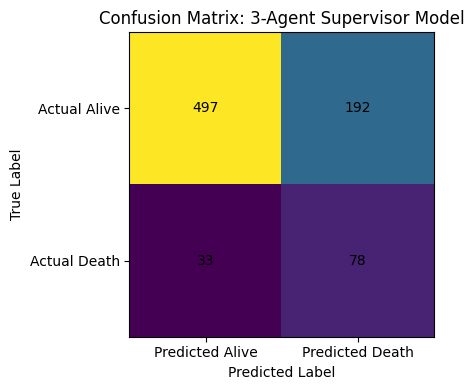

Saved: /content/drive/MyDrive/icu_3_agent_project/results/confusion_matrix_supervisor.png


In [44]:
import matplotlib.pyplot as plt
import numpy as np

cm = three_agent_metrics["supervisor_confusion_matrix"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted Alive", "Predicted Death"])
ax.set_yticklabels(["Actual Alive", "Actual Death"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i][j], ha="center", va="center")

ax.set_title("Confusion Matrix: 3-Agent Supervisor Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

confusion_path = f"{project_dir}/results/confusion_matrix_supervisor.png"
plt.savefig(confusion_path, dpi=300)
plt.show()

print("Saved:", confusion_path)

### Save Example Rule-Based Agent Explanations

This cell loads the saved rule-based prediction results and selects a small set of example explanations.

The selected table includes each patient’s ID, true outcome label, individual agent risk levels, overall risk level, and the final explanation generated by the supervisor agent.

Only the first 20 examples are saved to `example_explanations.csv`, and the first 10 are displayed in the notebook. These examples are useful for showing how the rule-based multi-agent system explains its predictions.

In [45]:
pred_df = pd.read_csv(f"{project_dir}/results/rule_based_predictions.csv")

example_explanations = pred_df[
    ["RecordID", "true_label", "kidney_risk", "vital_risk", "ventilation_risk", "overall_risk", "final_explanation"]
].head(20)

example_path = f"{project_dir}/results/example_explanations.csv"
example_explanations.to_csv(example_path, index=False)

example_explanations.head(10)

,RecordID,true_label,kidney_risk,vital_risk,ventilation_risk,overall_risk,final_explanation
0,132539.0,0.0,low,low,low,low,"No major kidney, vital sign, or ventilation ri..."
1,132540.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of lo...
2,132541.0,0.0,low,low,high,medium,Mechanical Ventilation Agent says high risk be...
3,132543.0,0.0,low,low,low,low,"No major kidney, vital sign, or ventilation ri..."
4,132545.0,0.0,low,low,low,low,"No major kidney, vital sign, or ventilation ri..."
5,132547.0,0.0,low,high,medium,medium,Vital Signs Agent says high risk because of lo...
6,132548.0,0.0,medium,low,low,low,Kidney Failure Agent says medium risk because ...
7,132551.0,1.0,low,medium,high,high,Vital Signs Agent says medium risk because of ...
8,132554.0,0.0,low,medium,low,low,Vital Signs Agent says medium risk because of ...
9,132555.0,0.0,low,high,high,high,Vital Signs Agent says high risk because of lo...


### Visualize AUROC and AUPRC for Each ML Agent

This cell creates bar charts to compare the AUROC and AUPRC scores of the kidney agent, vital signs agent, ventilation agent, and supervisor agent.

AUROC shows how well each model separates patients who survived from patients who died in the hospital. AUPRC is especially useful for imbalanced datasets, where the number of deaths is smaller than the number of survivors.

The charts are saved as image files in the `results` folder so they can be used in the final report or presentation.

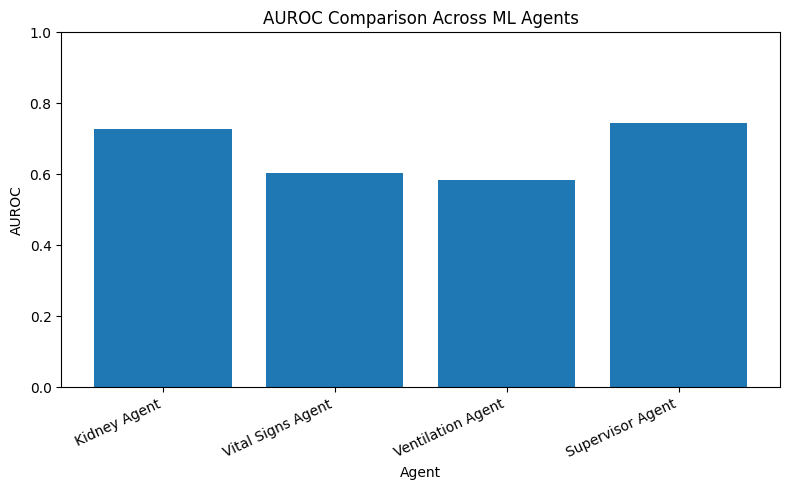

Saved AUROC plot: /content/drive/MyDrive/icu_3_agent_project/results/auroc_agent_comparison.png


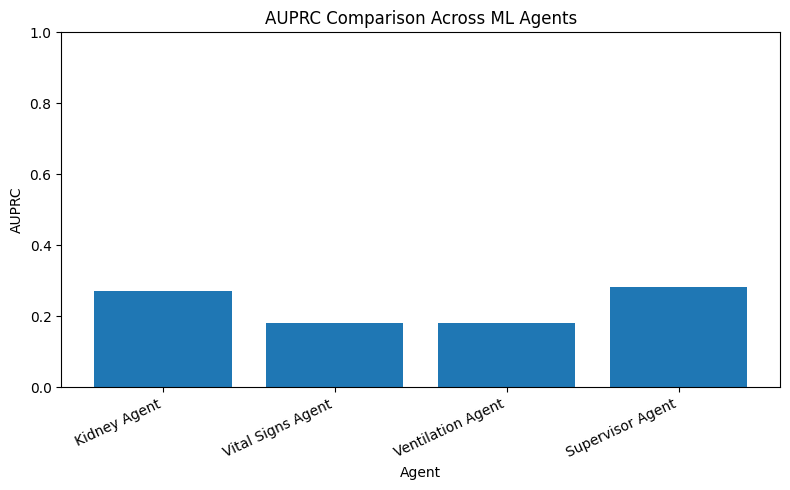

Saved AUPRC plot: /content/drive/MyDrive/icu_3_agent_project/results/auprc_agent_comparison.png


In [46]:
# Import plotting library
import matplotlib.pyplot as plt
import pandas as pd

# Create a table for AUROC and AUPRC values for each ML agent
agent_plot_df = pd.DataFrame([
    {
        "Agent": "Kidney Agent",
        "AUROC": three_agent_metrics.get("kidney_auroc"),
        "AUPRC": three_agent_metrics.get("kidney_auprc")
    },
    {
        "Agent": "Vital Signs Agent",
        "AUROC": three_agent_metrics.get("vital_auroc"),
        "AUPRC": three_agent_metrics.get("vital_auprc")
    },
    {
        "Agent": "Ventilation Agent",
        "AUROC": three_agent_metrics.get("ventilation_auroc"),
        "AUPRC": three_agent_metrics.get("ventilation_auprc")
    },
    {
        "Agent": "Supervisor Agent",
        "AUROC": three_agent_metrics.get("supervisor_auroc"),
        "AUPRC": three_agent_metrics.get("supervisor_auprc")
    }
])

# -----------------------------
# AUROC bar chart
# -----------------------------

plt.figure(figsize=(8, 5))
plt.bar(agent_plot_df["Agent"], agent_plot_df["AUROC"])

plt.title("AUROC Comparison Across ML Agents")
plt.xlabel("Agent")
plt.ylabel("AUROC")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

auroc_plot_path = f"{project_dir}/results/auroc_agent_comparison.png"
plt.savefig(auroc_plot_path, dpi=300)
plt.show()

print("Saved AUROC plot:", auroc_plot_path)


# -----------------------------
# AUPRC bar chart
# -----------------------------

plt.figure(figsize=(8, 5))
plt.bar(agent_plot_df["Agent"], agent_plot_df["AUPRC"])

plt.title("AUPRC Comparison Across ML Agents")
plt.xlabel("Agent")
plt.ylabel("AUPRC")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

auprc_plot_path = f"{project_dir}/results/auprc_agent_comparison.png"
plt.savefig(auprc_plot_path, dpi=300)
plt.show()

print("Saved AUPRC plot:", auprc_plot_path)

# Final Project Report: ICU Deterioration Prediction Multi-Agent System

## 1. Project Overview
This project developed and evaluated a multi-agent system designed to predict in-hospital mortality (deterioration) for ICU patients using the PhysioNet 2012 dataset. The system analyzes data from the first 24 hours of an ICU stay across three clinical domains: Kidney Function, Vital Signs, and Respiratory/Ventilation status.

## 2. Methodology
- **Data Extraction:** Raw time-series patient data was processed to extract 77 clinical features, including static values (age, weight) and 24-hour summary statistics (min, max, mean, trend) for labs and vitals.
- **Rule-Based Agents:** Clinical logic was implemented to assign risk levels (Low, Medium, High) based on medical thresholds.
- **ML Baseline:** A standard Logistic Regression model was trained on all features as a performance benchmark.
- **Multi-Agent ML System:** Three specialized ML agents were trained on domain-specific feature groups (Kidney, Vitals, Ventilation). Their individual risk probabilities were combined by a 'Supervisor Agent' model.

## 3. Performance Summary
Based on the experimental results, we compared the three different approaches:


In [47]:
# Display the results table for the report
display(results_table)

,Model,Accuracy,Precision,Recall,F1,AUROC,AUPRC
0,Rule-based 3-agent system,0.41275,0.167716,0.817690,0.278341,NaN,NaN
1,ML baseline using all features,0.71750,0.290909,0.720721,0.414508,0.765897,0.291546
2,3 ML agents + supervisor,0.71875,0.288889,0.702703,0.409449,0.743890,0.284080


## 4. Key Findings
- **Rule-Based System:** Achieved the highest **Recall (81.7%)**, making it effective at catching high-risk patients, but suffered from low **Accuracy (41.2%)** due to many false alarms.
- **Machine Learning Performance:** Both the ML Baseline and the 3-Agent ML System significantly improved accuracy, reaching approximately **71.8%**.
- **Modular Insights:** The 3-Agent system provides granular insights. For example, the **Kidney Failure Agent** demonstrated the strongest individual predictive power (AUROC 0.72) compared to the Vital Signs and Ventilation agents.
- **Supervisor Benefit:** The Supervisor Agent (AUROC 0.74) successfully synthesized information from the specialized agents to maintain high predictive performance while allowing for modular clinical explanations.

## 5. Conclusion
The multi-agent ML approach matches baseline performance while offering superior interpretability. By identifying specifically which physiological system is driving a 'High Risk' prediction, the system provides actionable insights for clinical intervention.